In [1]:
import numpy as np

from matplotlib import pyplot as plt

from pathlib import Path

import json

from scipy import stats


In [2]:
# DATA_DIR = Path("../../artifacts/2023-06-s7/dev/toy-experiments")
DATA_DIR = Path("../../artifacts/2023-06-s8/toy-experiments/gaussian-blobs")
# DATA_DIR = Path("../../artifacts/2023-06-s8/toy-experiments/gaussian-blobs-nc10")

In [3]:
def load_auroc(
    eps, seeds,
    subset_slug,
    basis_name,
    model, layer,
    covdiag,
):
    
    merged_key = "auroc"
    
    
    merged_stat = dict()
    
    arr_aurocs = []
    arr_area_aurocs = []
    arr_teacher_aurocs = []
    
    for six, seed in enumerate(seeds):
        
        file = DATA_DIR / f"toy-dataset-eps{eps}-covdiag{covdiag}-seed{seed}" / model / f"subdataset--{subset_slug}" / layer / basis_name / "auroc.json"


        with open(file, "r") as fh:
            _stat = json.load(fh)
                        
        ks = np.array(_stat["ks"])
        if six == 0:
            merged_stat["ks"] = ks
        else:
            assert (merged_stat["ks"] == ks).all()
        
        auroc = np.array(_stat["auroc"])
        auroc = np.where(auroc < 0.5, 1-auroc, auroc)
        
        
        assert ks[0] == 0
        
        # ks = [0, 1, ..., d]
        # auroc: shape = (num ks,)
        area_auroc_varying_k = np.trapz(
            auroc,
            dx=1/ks[-1]
        )
        
        
        arr_aurocs.append(auroc)
        arr_area_aurocs.append(area_auroc_varying_k)
        arr_teacher_aurocs.append(auroc[-1])
        
    # shape: (num_seeds, len(ks))
    arr_aurocs = np.vstack(arr_aurocs)
    
    nseeds = len(seeds)
    assert arr_aurocs.shape[0] ==  nseeds
    
    merged_stat["mean_auroc"] = np.mean(arr_aurocs, axis=0)
    merged_stat["stderr_auroc"] = stats.sem(arr_aurocs, axis=0)
    
    
    merged_stat["mean_area_auroc"] = np.mean(arr_area_aurocs, axis=0)
    merged_stat["stderr_area_auroc"] = stats.sem(arr_area_aurocs, axis=0)
    
    
    merged_stat['mean_teacher_auroc'] = np.mean(arr_teacher_aurocs)
    merged_stat['std_teacher_auroc'] = stats.sem(arr_teacher_aurocs)

    return merged_stat

    
load_auroc(
    eps=0.5,
    seeds=range(1, 2+1), 
    subset_slug="p0",
    model="mlp16", 
    basis_name="pca--centered",
    layer="act1",
    covdiag=False
)

{'ks': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 'mean_auroc': array([0.5       , 0.51945062, 0.62479939, 0.66360448, 0.67531893,
        0.67493892, 0.67509781, 0.67317848, 0.67348012, 0.67418711,
        0.67439888, 0.67445585, 0.67444159, 0.67448434, 0.67448434,
        0.67448434, 0.67448434]),
 'stderr_auroc': array([0.00000000e+00, 9.35345888e-05, 8.30365717e-03, 2.53413767e-02,
        2.98092663e-02, 2.48331726e-02, 2.54150182e-02, 2.69639343e-02,
        2.77449191e-02, 2.74368078e-02, 2.72820443e-02, 2.73390114e-02,
        2.73247510e-02, 2.73675025e-02, 2.73675025e-02, 2.73675025e-02,
        2.73675025e-02]),
 'mean_area_auroc': 0.6555029610171914,
 'stderr_area_auroc': 0.022316652350127697,
 'mean_teacher_auroc': 0.6744843423366547,
 'std_teacher_auroc': 0.027367502450942993}

We have 7 beta values!: ['0.001', '0.01', '0.1', '1.0', '10.0', '100.0', '1000.0']


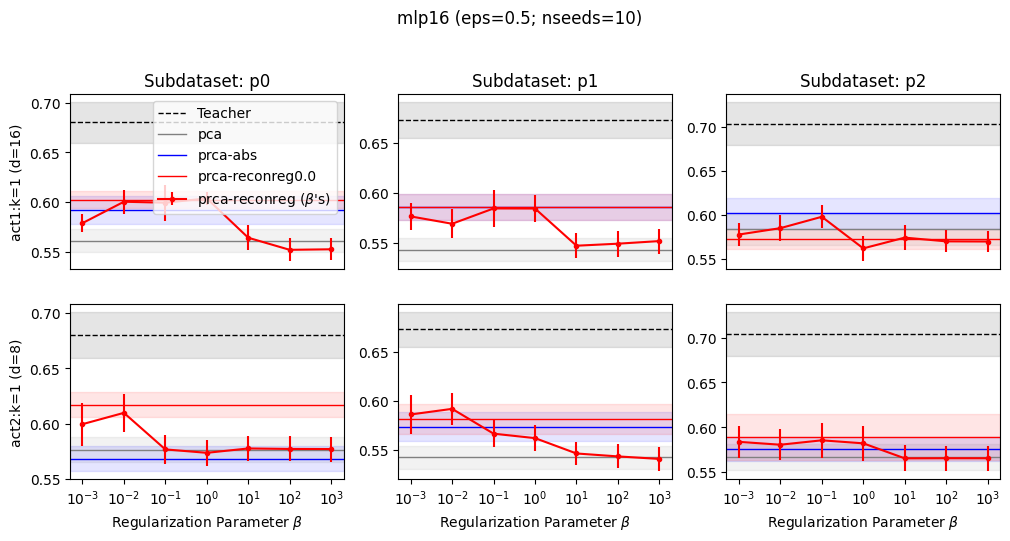

In [4]:
def get_auroc_at_k(k, **kwargs):
    
    result = load_auroc(**kwargs)
    
    return result["mean_auroc"][k], result["stderr_auroc"][k]

def axhline(mean, stderr, **kwargs):

    plt.axhline(mean, **kwargs)
    plt.axhspan(mean - stderr, mean + stderr, color=plt.gca().lines[-1].get_color(), alpha=0.1)
    

def viz(
    eps,
    layers=["act1", "act2"]
):
    seeds = list(range(1, 10 +1))
    basis_names = [
        "pca",
        "prca-abs",
        "prca-reconreg0.0",
        "prca-reconreg0.001",
        "prca-reconreg0.01",
        "prca-reconreg0.1",
        "prca-reconreg1.0",
        "prca-reconreg10.0",
        "prca-reconreg100.0",
        "prca-reconreg1000.0",
    ]
    
    
    arr_betas = []
    
    for basis in basis_names:
        if "reconreg" in basis:
            beta = basis.split("reconreg")[-1] 
            if beta != "0.0":
                arr_betas.append(beta)

            
    print(f"We have {len(arr_betas)} beta values!: {arr_betas}")
    
    class_pairs = [
        "p0",
        "p1",
        "p2"
    ]
    

    arch = "mlp16"
    covdiag = False
    k = 1
    
    ncols = len(class_pairs)
    nrows = len(layers)
    
    plt.figure(figsize=(4*ncols, 2.5*nrows))
    plt.suptitle(f"{arch} (eps={eps}; nseeds={len(seeds)})", y=1.05)
    for lix, layer in enumerate(layers):
        for pix, subset_slug in enumerate(class_pairs):
            plt.subplot(nrows, ncols, lix * ncols + pix +1)

            
            result_pca = load_auroc(
                model=arch,  basis_name="pca--centered", layer=layer,eps=eps, seeds=seeds, 
                subset_slug=subset_slug,
                covdiag=covdiag
            )
            
            # todo: we now actually do not +1
            d = result_pca["ks"][-1] 

            auroc_mean_pca, auroc_stderr_pca = get_auroc_at_k(
                k,
                model=arch,  
                basis_name="pca--centered", layer=layer,eps=eps, seeds=seeds, 
                subset_slug=subset_slug,
                covdiag=covdiag
            )

    
            
            auroc_mean_prca_abs, auroc_stderr_prca_abs = get_auroc_at_k(
                k,
                model=arch,  basis_name="prca-abs--centered", layer=layer,eps=eps, seeds=seeds, subset_slug=subset_slug,
                covdiag=covdiag
            )

            auroc_mean_prca_reconreg00, auroc_std_prca_reconreg00 = get_auroc_at_k(
                k,
                model=arch,  basis_name="prca-reconreg0.0--centered", layer=layer,eps=eps, seeds=seeds, subset_slug=subset_slug,
                covdiag=covdiag
            )
            
            # todo: need has to be d
            auroc_mean_teacher, auroc_stderr_teacher = get_auroc_at_k(
                d,
                model=arch,  basis_name="pca--centered", layer=layer,eps=eps, seeds=seeds, subset_slug=subset_slug,
                covdiag=covdiag
            )

            axhline(auroc_mean_teacher, auroc_stderr_teacher, ls="--", lw=1, color="k", label="Teacher")
            axhline(auroc_mean_pca, auroc_stderr_pca, ls="-", lw=1, color="gray", label="pca")
            
            axhline(auroc_mean_prca_abs, auroc_stderr_prca_abs, ls="-", lw=1, color="b", label="prca-abs")
            axhline(auroc_mean_prca_reconreg00, auroc_std_prca_reconreg00, ls="-", lw=1, color="r", label="prca-reconreg0.0")


            arr_stats = []
            for beta in arr_betas:
                _auroc_mean, _auroc_stderr = get_auroc_at_k(
                    k,
                    basis_name=f"prca-reconreg{beta}--centered",
                    model=arch, 
                    layer=layer,
                    eps=eps,
                    seeds=seeds, 
                    subset_slug=subset_slug,
                    covdiag=covdiag
                )
                
                arr_stats.append((_auroc_mean, _auroc_stderr))
                
            arr_stats = np.array(arr_stats)

            plt.errorbar(
                np.array(arr_betas).astype(float),
                arr_stats[:, 0],
                arr_stats[:, 1],
                marker=".",
                color="r",
                label=r"prca-reconreg ($\beta$'s)"
            )
#             plt.fill_between(
#                 np.array(arr_betas).astype(float),
#                 arr_stats[:, 0] - arr_stats[:, 1],
#                 arr_stats[:, 0] + arr_stats[:, 1],
#                 color="r",
#                 alpha=0.05
#             )
                
            # end for basis
            plt.xscale("log")
            plt.xticks(np.array(arr_betas).astype(float))
            if lix == pix == 0: plt.legend()
            
            if lix == 0:
                plt.title(f"Subdataset: {subset_slug}")  

            if lix != len(layers) - 1:
                plt.xticks([])

            if pix == 0: plt.ylabel(f"{layer}:k={k} (d={d})")
            if lix == nrows - 1: plt.xlabel(r"Regularization Parameter $\beta$")
    
viz(eps=0.5)

We have 7 beta values!: ['0.001', '0.01', '0.1', '1.0', '10.0', '100.0', '1000.0']
We have 7 beta values!: ['0.001', '0.01', '0.1', '1.0', '10.0', '100.0', '1000.0']
We have 7 beta values!: ['0.001', '0.01', '0.1', '1.0', '10.0', '100.0', '1000.0']


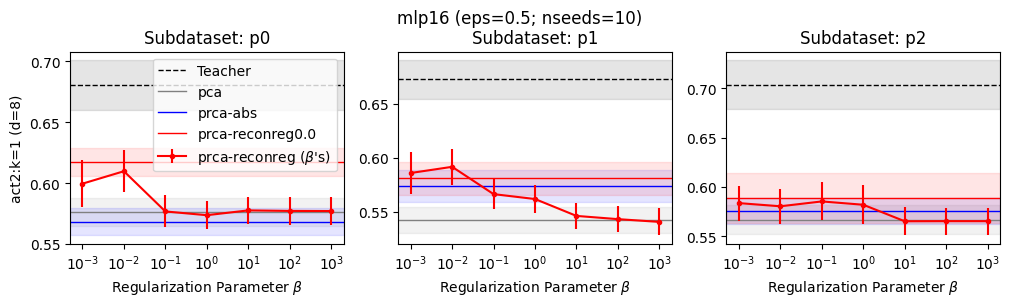

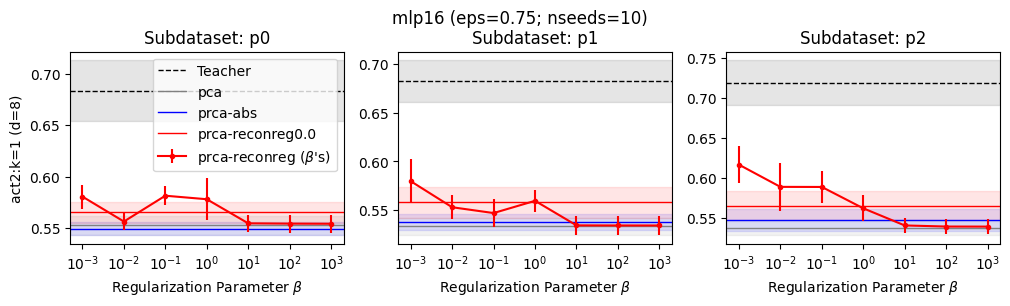

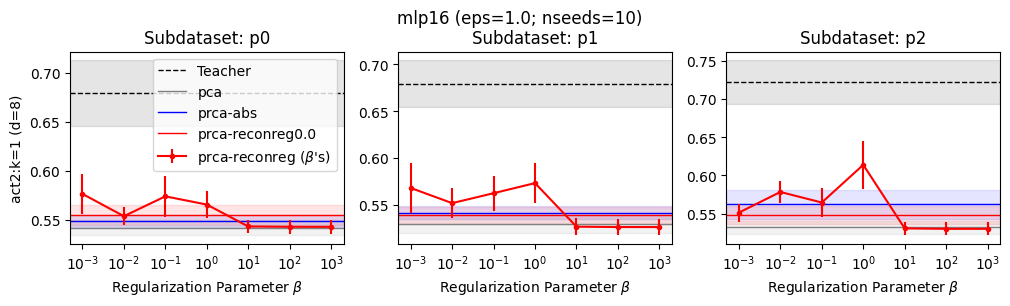

In [5]:
def ano():
    for eps in [0.5, 0.75, 1.0]:
        viz(eps=eps, layers=["act2"])
ano()

We have 7 beta values!: ['0.001', '0.01', '0.1', '1.0', '10.0', '100.0', '1000.0']
We have 7 beta values!: ['0.001', '0.01', '0.1', '1.0', '10.0', '100.0', '1000.0']
We have 7 beta values!: ['0.001', '0.01', '0.1', '1.0', '10.0', '100.0', '1000.0']


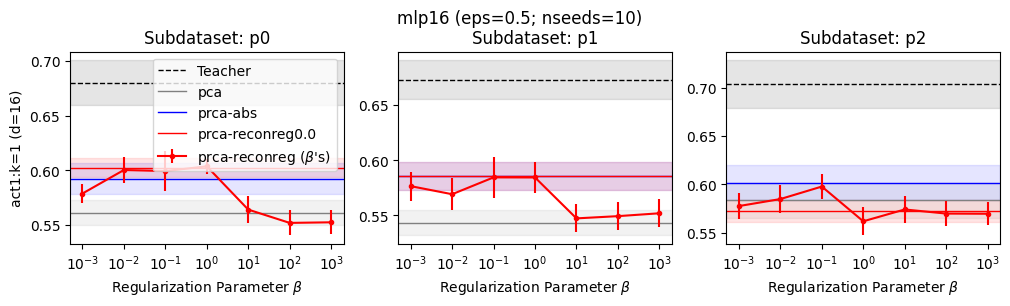

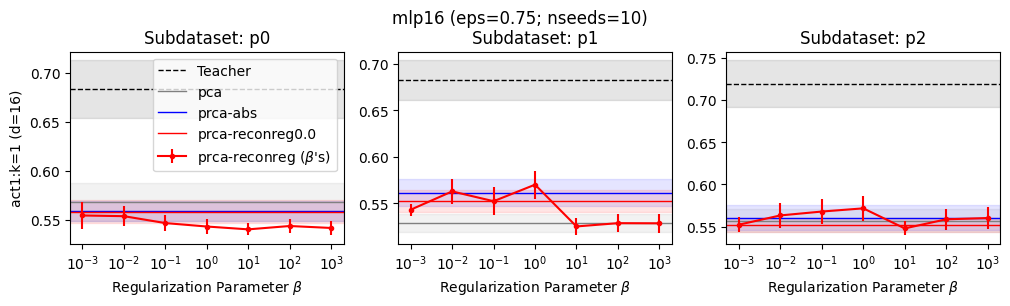

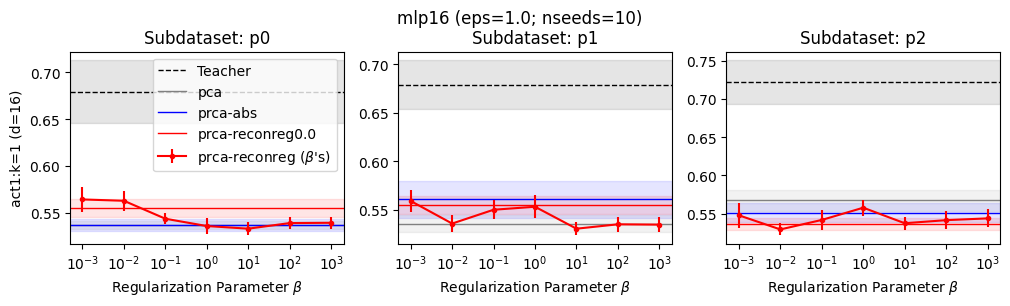

In [6]:
def ano():
    for eps in [0.5, 0.75, 1.0]:
        viz(eps=eps, layers=["act1"])
ano()